# v2-3. 월부담액 다시 정의하고 모델 다듬기
02 노트북에서 정한 것 그대로 씀 (건물 단위 5-fold, holdout 건물 20%, v2 반경 조합)

#### 이 노트북에서 하는 것
1. 전환율 4% 대신 데이터로 전환율 찾기
2. 4% vs 찾은 전환율 비교
3. 튜닝
4. 추가로 넣어본 변수 (위경도, 주변 시세)
5. 최종 시험 (holdout, 한 번만)
6. SHAP으로 다시 해석
7. 오차가 큰 곳

In [1]:
import json
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

warnings.filterwarnings('ignore')
import shap
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import BallTree

if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/rent_v2.csv.gz')
holdout = set(pd.read_csv('data/holdout_buildings.csv')['건물'])
with open('data/v2_features.json', encoding='utf-8') as f:
    feat = json.load(f)
기본변수리스트 = feat['기본변수리스트']
print(df.shape, len(holdout))

(122019, 51) 7347


In [2]:
# 건물 묶기 (02 노트북이랑 같은 기준)
parent = {}

def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    parent[find(a)] = find(b)

for 주소, 구, 동, 도로명주소, 건물명, 주택유형 in df[['주소', '구', '동', '도로명주소', '건물명', '주택유형']].drop_duplicates().itertuples(index=False):
    union('지번:' + 주소, '도로명:' + 구 + ' ' + str(도로명주소))
    if 주택유형 == '아파트' and isinstance(건물명, str):
        union('지번:' + 주소, '단지:' + 구 + ' ' + 동 + ' ' + 건물명)
df['건물'] = [find('지번:' + a) for a in df['주소']]
df['holdout'] = df['건물'].isin(holdout)
print(df.groupby('주택유형')['holdout'].mean().round(3))

주택유형
아파트      0.197
연립다세대    0.200
Name: holdout, dtype: float64


## 1. 전환율 찾기
v1에서는 보증금을 월 부담으로 바꿀 때 연 4%를 정해서 씀 (```월부담액 = 보증금 x 0.04 / 12 + 월세```)
같은 건물, 같은 면적, 같은 달에 보증금이 다른 계약끼리 비교하면 보증금이 늘 때 월세가 얼마나 줄어드는지 볼 수 있음

- 그룹(건물, 면적, 계약월) 안에서 평균을 빼고 회귀 (층 차이도 같이 넣어서 통제)
- ```월세 = a - (전환율 / 12) x 보증금 + b x 층``` -> 보증금 계수 x (-12) = 전환율

In [3]:
def find_rate(d, by=('건물', '면적', '계약월')):
    by = list(by)
    g = d.groupby(by)
    d = d[g['보증금(만원)'].transform('nunique') > 1]   # 보증금이 다른 계약이 있는 그룹만
    g = d.groupby(by)
    y = d['월세금(만원)'] - g['월세금(만원)'].transform('mean')
    X = np.column_stack([d[c] - g[c].transform('mean') for c in ['보증금(만원)', '층']])
    coef = np.linalg.lstsq(X, y.values, rcond=None)[0]
    return -coef[0] * 12, len(d), d[by].drop_duplicates().shape[0]

df['면적'] = df['전용면적(㎡)'].round(0)
rates = {}
for t in ['아파트', '연립다세대']:
    r, n, ng = find_rate(df[df['주택유형'] == t])
    rates[t] = round(float(r), 4)
    print(f'{t} : 전환율 {r * 100:.2f}%  (비교한 거래 {n}건, 그룹 {ng}개)')

아파트 : 전환율 4.35%  (비교한 거래 29580건, 그룹 8451개)
연립다세대 : 전환율 4.62%  (비교한 거래 4257건, 그룹 1730개)


In [4]:
# 보증금 크기별로 나눠서 보면
for t in ['아파트', '연립다세대']:
    d = df[df['주택유형'] == t]
    by = ['건물', '면적', '계약월']
    d = d[d.groupby(by)['보증금(만원)'].transform('nunique') > 1].copy()
    d['보증금 구간'] = pd.cut(d.groupby(by)['보증금(만원)'].transform('mean'), [0, 3000, 10000, 30000, 1e9],
                         labels=['3천 미만', '3천~1억', '1억~3억', '3억 이상'])
    print(t)
    for b, sub in d.groupby('보증금 구간', observed=True):
        r, n, ng = find_rate(sub)
        print(f'   {b:7s} 전환율 {r * 100:5.2f}%  (거래 {n}건)')

아파트
   3천 미만   전환율  4.76%  (거래 4712건)
   3천~1억   전환율  4.14%  (거래 8354건)
   1억~3억   전환율  4.17%  (거래 9865건)
   3억 이상   전환율  4.41%  (거래 6649건)
연립다세대
   3천 미만   전환율  0.00%  (거래 1541건)
   3천~1억   전환율  4.71%  (거래 1373건)
   1억~3억   전환율  4.73%  (거래 1285건)
   3억 이상   전환율  5.15%  (거래 58건)


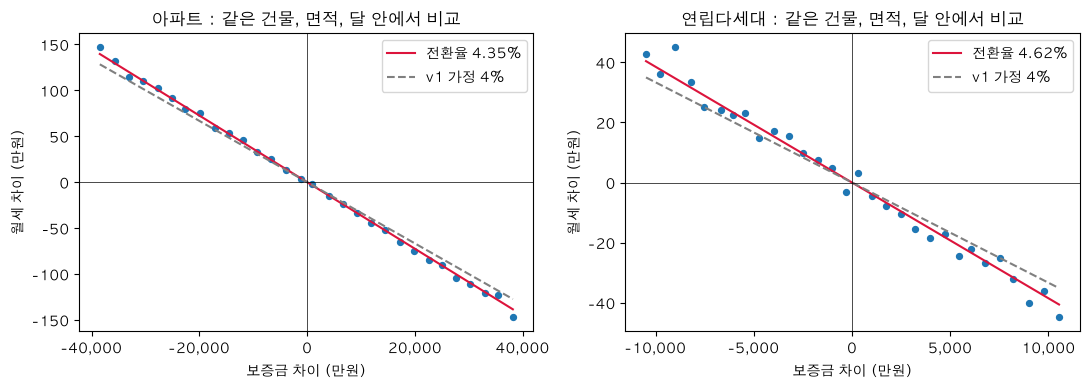

In [5]:
# 그림: 그룹 평균을 뺀 보증금 차이 vs 월세 차이
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, t in zip(axes, ['아파트', '연립다세대']):
    d = df[df['주택유형'] == t]
    by = ['건물', '면적', '계약월']
    d = d[d.groupby(by)['보증금(만원)'].transform('nunique') > 1]
    g = d.groupby(by)
    dx = d['보증금(만원)'] - g['보증금(만원)'].transform('mean')
    dy = d['월세금(만원)'] - g['월세금(만원)'].transform('mean')
    keep = dx.abs() < dx.abs().quantile(0.98)
    bins = pd.cut(dx[keep], 30)
    mx, my = dx[keep].groupby(bins, observed=True).mean(), dy[keep].groupby(bins, observed=True).mean()
    ax.scatter(mx, my, s=18)
    xs = np.linspace(mx.min(), mx.max(), 50)
    ax.plot(xs, -rates[t] / 12 * xs, color='crimson', label=f'전환율 {rates[t] * 100:.2f}%')
    ax.plot(xs, -0.04 / 12 * xs, color='gray', ls='--', label='v1 가정 4%')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'{t} : 같은 건물, 면적, 달 안에서 비교')
    ax.set_xlabel('보증금 차이 (만원)')
    ax.set_ylabel('월세 차이 (만원)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:,.0f}'))
    ax.legend()
plt.tight_layout()
plt.savefig('images/03_rate.png', dpi=120)
plt.show()

-> 아파트, 연립다세대 둘 다 4%보다 조금 높게 나옴
(참고로 계약 기간 중에 보증금 일부를 월세로 돌릴 때 법으로 정한 상한이 기준금리 + 2%p 인데, 2024년 기준금리가 3.0~3.5%라 5.0~5.5%. 찾은 값은 그 안쪽)

보증금 크기별로 보면
- 아파트는 구간마다 4.1~4.8%로 비슷함
- 연립다세대는 보증금 3천만원 미만에서 보증금이 달라도 월세가 거의 안 바뀜(0%). 작은 보증금은 가격이라기보다 담보 성격으로 보임
- 연립 전체 값(4.62%)은 3천만원 이상 구간(4.7%)이랑 비슷해서 그대로 씀. 대신 보증금이 작은 연립은 서비스의 "보증금 바꿔보기"가 덜 맞을 수 있음

## 2. 4% vs 찾은 전환율
타겟 값 자체가 바뀌니까 RMSE, MAE 대신 **평균 오차율(MAPE)**이랑 R^2, 중요 변수 순위로 비교

In [6]:
P0 = {}   # v1 설정 (XGBoost 기본값)
P1 = dict(n_estimators=800, learning_rate=0.05, max_depth=8, min_child_weight=5, subsample=0.8, colsample_bytree=0.8)

df['월부담액_4%'] = df['보증금(만원)'] * 0.04 / 12 + df['월세금(만원)']
df['월부담액'] = df['보증금(만원)'] * df['주택유형'].map(rates) / 12 + df['월세금(만원)']

def cv_group(d, cols, target, params, n_splits=5, return_oof=False):
    """dev 안에서 건물 단위 5-fold"""
    oof = np.zeros(len(d))
    fold_r2 = []
    gkf = GroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr, te in gkf.split(d, groups=d['건물']):
        model = xgb.XGBRegressor(random_state=42, verbosity=0, **params)
        model.fit(d[cols].iloc[tr], d[target].iloc[tr])
        oof[te] = model.predict(d[cols].iloc[te])
        fold_r2.append(r2_score(d[target].iloc[te], oof[te]))
    y = d[target]
    res = {'R^2': round(r2_score(y, oof), 4), 'fold 표준편차': round(np.std(fold_r2), 4),
           'MAE': round(mean_absolute_error(y, oof), 2), 'MAPE': round(np.mean(np.abs(oof - y) / y), 4)}
    return (res, oof) if return_oof else res

dev = {t: df[(df['주택유형'] == t) & ~df['holdout']].reset_index(drop=True) for t in ['아파트', '연립다세대']}
cols = {t: 기본변수리스트 + feat[t] for t in ['아파트', '연립다세대']}

In [7]:
rows = []
top5 = {}
for t in ['아파트', '연립다세대']:
    for target in ['월부담액_4%', '월부담액']:
        rows.append({'주택유형': t, '타겟': target} | cv_group(dev[t], cols[t], target, P1))
        m = xgb.XGBRegressor(random_state=42, verbosity=0, **P1).fit(dev[t][cols[t]], dev[t][target])
        top5[(t, target)] = pd.Series(m.feature_importances_, index=cols[t]).sort_values(ascending=False).index[:5].tolist()
print(pd.DataFrame(rows).to_string(index=False))
print()
for k, v in top5.items():
    print(k, v)

 주택유형      타겟    R^2  fold 표준편차   MAE   MAPE
  아파트 월부담액_4% 0.8402     0.0310 32.89 0.2216
  아파트    월부담액 0.8466     0.0282 33.10 0.2190
연립다세대 월부담액_4% 0.6606     0.0989 16.74 0.2234
연립다세대    월부담액 0.6628     0.0952 17.04 0.2196

('아파트', '월부담액_4%') ['전용면적(㎡)', '자치구코드', '법정동코드', '0-19대인구비', '건축년도']
('아파트', '월부담액') ['전용면적(㎡)', '자치구코드', '법정동코드', '0-19대인구비', '건축년도']
('연립다세대', '월부담액_4%') ['연립다세대_거래수', '자치구코드', '전용면적(㎡)', '건축년도', '아파트_거래수']
('연립다세대', '월부담액') ['연립다세대_거래수', '전용면적(㎡)', '자치구코드', '아파트_거래수', '건축년도']


-> 성능도 비슷하고 중요 변수 순위도 거의 그대로라 4% 가정 때문에 결론이 바뀌진 않음
그래도 서비스에서 "보증금을 1,000만원 올리면 월세가 얼마나 내려가야 맞는지" 계산할 때는 실제 시장 비율이 맞아야 해서 v2부터는 찾은 전환율로 씀

## 3. 튜닝
v1은 XGBoost 기본값(트리 100개, 학습률 0.3, 깊이 6)이었음. 트리를 늘리고 학습률을 낮춘 설정이랑 비교

In [8]:
P2 = dict(n_estimators=1500, learning_rate=0.03, max_depth=8, min_child_weight=10, subsample=0.8, colsample_bytree=0.7)
rows = []
for t in ['아파트', '연립다세대']:
    for name, P in [('P0 (기본값)', P0), ('P1', P1), ('P2', P2)]:
        rows.append({'주택유형': t, '설정': name} | cv_group(dev[t], cols[t], '월부담액', P))
tune_table = pd.DataFrame(rows)
print(tune_table.to_string(index=False))

 주택유형       설정    R^2  fold 표준편차   MAE   MAPE
  아파트 P0 (기본값) 0.8363     0.0245 35.79 0.2331
  아파트       P1 0.8466     0.0282 33.10 0.2190
  아파트       P2 0.8389     0.0353 33.87 0.2280
연립다세대 P0 (기본값) 0.6189     0.1079 17.40 0.2241
연립다세대       P1 0.6628     0.0952 17.04 0.2196
연립다세대       P2 0.6805     0.0889 16.98 0.2193


-> 기본값보다 P1, P2가 확실히 좋음. 아파트는 P1이 제일 좋고, 연립다세대는 P2가 R^2는 조금 높은데 오차율은 거의 같아서 둘 다 학습이 빠른 P1로 통일

## 4. 추가로 넣어본 변수
- ```위도```, ```경도``` : 같은 동 안에서도 위치 차이를 보라고
- ```주변_㎡당월부담액``` : 반경 1km 안 **다른 건물**들의 ㎡당 월부담액 평균 (자기 건물은 뺌)
  - fold마다 train 건물로만 계산해서 test 건물 정보가 안 섞이게 함

fold 표준편차보다 작게 좋아지면 안 넣기로 함

In [9]:
def add_nearby(d, tr, r_km=1.0):
    """train 건물로만 반경 r_km 안 다른 건물의 ㎡당 월부담액 평균"""
    ppm = d['월부담액'] / d['전용면적(㎡)']
    b = pd.DataFrame({'건물': d['건물'], '위도': d['위도'], '경도': d['경도'], 'ppm': ppm})
    b_tr = b.iloc[tr].groupby('건물').agg(위도=('위도', 'mean'), 경도=('경도', 'mean'), s=('ppm', 'sum'), n=('ppm', 'size'))
    b_all = b.groupby('건물').agg(위도=('위도', 'mean'), 경도=('경도', 'mean'))
    tree = BallTree(np.radians(b_tr[['위도', '경도']].values), metric='haversine')
    ind = tree.query_radius(np.radians(b_all[['위도', '경도']].values), r=r_km / 6371.0)
    s_arr, n_arr = b_tr['s'].values, b_tr['n'].values
    pos = {k: i for i, k in enumerate(b_tr.index)}
    val = []
    for k, nb in zip(b_all.index, ind):
        s, n = s_arr[nb].sum(), n_arr[nb].sum()
        if k in pos:                       # 자기 건물은 빼기
            s, n = s - s_arr[pos[k]], n - n_arr[pos[k]]
        val.append(s / n if n > 0 else np.nan)
    return d['건물'].map(pd.Series(val, index=b_all.index))

def cv_group_nearby(d, cols, params, n_splits=5):
    oof = np.zeros(len(d))
    fold_r2 = []
    gkf = GroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr, te in gkf.split(d, groups=d['건물']):
        dd = d.copy()
        dd['주변_㎡당월부담액'] = add_nearby(dd, tr)
        c = cols + ['주변_㎡당월부담액']
        model = xgb.XGBRegressor(random_state=42, verbosity=0, **params).fit(dd[c].iloc[tr], dd['월부담액'].iloc[tr])
        oof[te] = model.predict(dd[c].iloc[te])
        fold_r2.append(r2_score(dd['월부담액'].iloc[te], oof[te]))
    y = d['월부담액']
    return {'R^2': round(r2_score(y, oof), 4), 'fold 표준편차': round(np.std(fold_r2), 4),
            'MAE': round(mean_absolute_error(y, oof), 2), 'MAPE': round(np.mean(np.abs(oof - y) / y), 4)}

rows = []
for t in ['아파트', '연립다세대']:
    rows.append({'주택유형': t, '변수': 'v2 기본'} | cv_group(dev[t], cols[t], '월부담액', P1))
    rows.append({'주택유형': t, '변수': '+ 위경도'} | cv_group(dev[t], cols[t] + ['위도', '경도'], '월부담액', P1))
    rows.append({'주택유형': t, '변수': '+ 위경도 + 주변 시세'} | cv_group_nearby(dev[t], cols[t] + ['위도', '경도'], P1))
print(pd.DataFrame(rows).to_string(index=False))

 주택유형            변수    R^2  fold 표준편차   MAE   MAPE
  아파트         v2 기본 0.8466     0.0282 33.10 0.2190
  아파트         + 위경도 0.8547     0.0287 32.45 0.2123
  아파트 + 위경도 + 주변 시세 0.8496     0.0288 34.20 0.2231
연립다세대         v2 기본 0.6628     0.0952 17.04 0.2196
연립다세대         + 위경도 0.6781     0.0888 16.90 0.2181
연립다세대 + 위경도 + 주변 시세 0.6592     0.0881 17.04 0.2191


- 위경도 : 조금 좋아지긴 함(아파트 R^2 +0.008, 연립 +0.015). 그런데 fold 표준편차보다 작고, SHAP으로 설명하면 "위도 +5만원" 같은 식이라 세입자한테 설명이 안 됨  
  -> 이 프로젝트는 **왜 그 가격인지 설명하는 게** 중요해서 설명 되는 변수만 남기고 뺌
- 주변 시세 : 오히려 나빠져서 뺌. 같은 구, 동, 연식 정보가 이미 있어서 주변 평균이 새 정보가 별로 없는 것으로 보임

## 5. 최종 시험 (holdout 건물, 한 번만)
dev 전체로 학습해서 처음 보는 holdout 건물에 한 번만 평가
v1 설정(기본값 + v1 반경)도 같은 데이터, 같은 holdout으로 같이 봄

In [10]:
v1_cols = {'아파트': 기본변수리스트 + ['병원_1km내_개수', '500m_이내_역_개수', '식당_0.5km내_개수', '공원_800m_이내_개수', '파출소/지구대_1km내_개수', '대학_2km내_개수'],
           '연립다세대': 기본변수리스트 + ['병원_1km내_개수', '1km_이내_역_개수', '식당_0.5km내_개수', '공원_500m_이내_개수', '파출소/지구대_0.5km내_개수', '대학_1km내_개수']}

def evaluate(y, p):
    return {'RMSE': round(np.sqrt(mean_squared_error(y, p)), 2), 'MAE': round(mean_absolute_error(y, p), 2),
            'R^2': round(r2_score(y, p), 4), 'MAPE': round(np.mean(np.abs(p - y) / y), 4),
            '오차율 중앙값': round(np.median(np.abs(p - y) / y), 4)}

final_models = {}
hold = {t: df[(df['주택유형'] == t) & df['holdout']].reset_index(drop=True) for t in ['아파트', '연립다세대']}
rows = []
for t in ['아파트', '연립다세대']:
    m1 = xgb.XGBRegressor(random_state=42, verbosity=0, **P0).fit(dev[t][v1_cols[t]], dev[t]['월부담액'])
    rows.append({'주택유형': t, '설정': 'v1 설정 (기본값, v1 반경)'} | evaluate(hold[t]['월부담액'], m1.predict(hold[t][v1_cols[t]])))
    m2 = xgb.XGBRegressor(random_state=42, verbosity=0, **P1).fit(dev[t][cols[t]], dev[t]['월부담액'])
    final_models[t] = m2
    rows.append({'주택유형': t, '설정': 'v2 설정 (P1, v2 반경)'} | evaluate(hold[t]['월부담액'], m2.predict(hold[t][cols[t]])))
holdout_table = pd.DataFrame(rows)
print('holdout 거래 수 :', {t: len(hold[t]) for t in hold})
print(holdout_table.to_string(index=False))

holdout 거래 수 : {'아파트': 11613, '연립다세대': 12601}
 주택유형                 설정  RMSE   MAE    R^2   MAPE  오차율 중앙값
  아파트 v1 설정 (기본값, v1 반경) 82.36 39.64 0.8221 0.2345   0.1278
  아파트  v2 설정 (P1, v2 반경) 83.87 37.81 0.8155 0.2160   0.1175
연립다세대 v1 설정 (기본값, v1 반경) 30.53 16.22 0.5893 0.2164   0.1259
연립다세대  v2 설정 (P1, v2 반경) 29.81 15.82 0.6084 0.2096   0.1258


- 처음 보는 건물 기준으로 v2 설정이 MAE, 평균 오차율, 오차율 중앙값 다 좋아짐
- 아파트 R^2는 오히려 조금 낮음(0.822 -> 0.816). RMSE도 같이 커진 걸 보면 아주 비싼 집 몇 건에서 크게 틀린 영향 (R^2는 큰 오차 몇 개에 많이 흔들림)
- 오차율 중앙값은 아파트 11.8%, 연립다세대 12.6% -> 처음 보는 건물이면 보통 10~13% 정도 틀림

### 이미 거래가 있는 건물이면?
서비스에서는 2024년에 거래가 있었던 건물을 고르게 할 거라, 그 건물의 다른 계약을 알고 있는 상황도 봐둠 (거래 단위 무작위 5-fold, v2 설정)

In [11]:
from sklearn.model_selection import KFold
rows = []
for t in ['아파트', '연립다세대']:
    d = df[df['주택유형'] == t].reset_index(drop=True)
    oof = np.zeros(len(d))
    for tr, te in KFold(5, shuffle=True, random_state=42).split(d):
        m = xgb.XGBRegressor(random_state=42, verbosity=0, **P1).fit(d[cols[t]].iloc[tr], d['월부담액'].iloc[tr])
        oof[te] = m.predict(d[cols[t]].iloc[te])
    rows.append({'주택유형': t, '상황': '거래가 있던 건물의 새 계약 (무작위 5-fold)'} | evaluate(d['월부담액'], oof))
print(pd.DataFrame(rows).to_string(index=False))

 주택유형                           상황  RMSE   MAE    R^2   MAPE  오차율 중앙값
  아파트 거래가 있던 건물의 새 계약 (무작위 5-fold) 43.74 20.56 0.9390 0.1340   0.0695
연립다세대 거래가 있던 건물의 새 계약 (무작위 5-fold) 28.43 13.90 0.7529 0.1853   0.1066


-> 같은 건물의 다른 계약을 알고 있으면 훨씬 잘 맞음 (아파트 오차율 중앙값 7%). 서비스의 적정 범위는 이 상황 기준으로 잡음 (streamlit/build_service.py)

## 6. SHAP으로 다시 해석
holdout 건물 중 3,000건으로 SHAP 계산 (값 단위가 만원이라 "평균적으로 월부담액을 몇 만원 움직였는지"로 읽으면 됨)

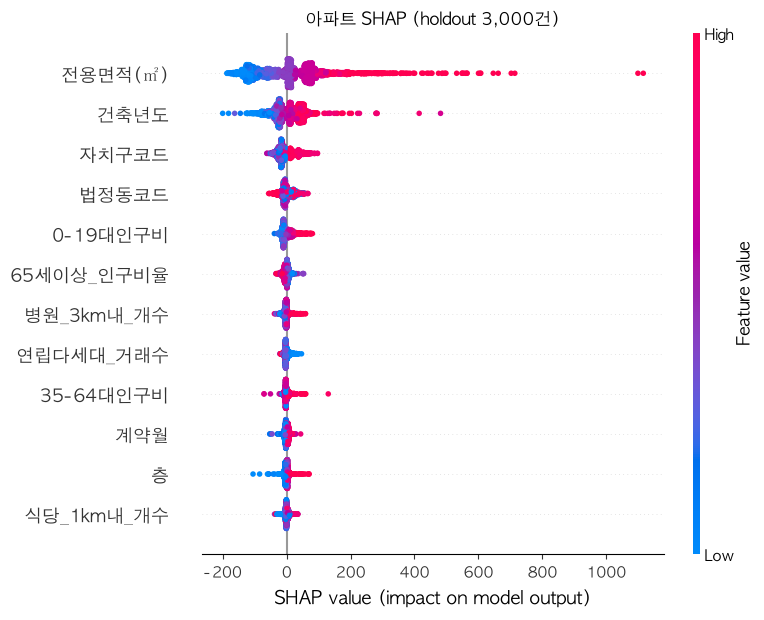

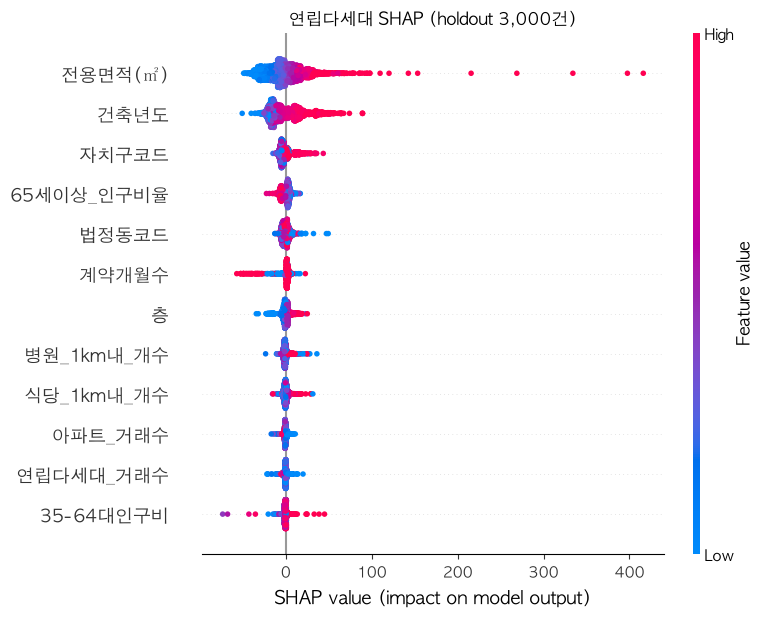

In [12]:
shap_rank = {}
for t, fname in [('아파트', 'apt'), ('연립다세대', 'vil')]:
    sample = hold[t][cols[t]].sample(min(3000, len(hold[t])), random_state=42)
    explainer = shap.TreeExplainer(final_models[t])
    sv = explainer(sample)
    shap_rank[t] = pd.Series(np.abs(sv.values).mean(axis=0), index=cols[t]).sort_values(ascending=False)
    plt.figure()
    shap.summary_plot(sv.values, sample, show=False, max_display=12)
    plt.title(f'{t} SHAP (holdout 3,000건)')
    plt.tight_layout()
    plt.savefig(f'images/03_shap_{fname}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [13]:
rank_table = pd.DataFrame({t: [f'{k} ({v:.1f}만원)' for k, v in shap_rank[t].head(8).items()] for t in shap_rank},
                          index=range(1, 9))
rank_table.index.name = '순위'
print(rank_table.to_string())

                   아파트               연립다세대
순위                                        
1     전용면적(㎡) (84.1만원)    전용면적(㎡) (17.0만원)
2        건축년도 (34.5만원)       건축년도 (15.0만원)
3       자치구코드 (21.5만원)       자치구코드 (4.9만원)
4       법정동코드 (12.7만원)  65세이상_인구비율 (3.5만원)
5    0-19대인구비 (12.5만원)       법정동코드 (3.1만원)
6   65세이상_인구비율 (5.6만원)       계약개월수 (2.9만원)
7   병원_3km내_개수 (5.1만원)           층 (2.9만원)
8    연립다세대_거래수 (5.0만원)  병원_1km내_개수 (1.8만원)


#### < SHAP 순위 ver.아파트 >
| 순위 | 변수 | 방향 |
| -- | -- | -- |
| 1 | 전용면적 | 넓을수록 비쌈 |
| 2 | 건축년도 | 신축일수록 비쌈 |
| 3 | 자치구 | 강남 3구 쪽이 비쌈 |
| 4 | 법정동 | 같은 구 안에서도 동네 차이 |
| 5 | 19세 이하 인구 비율 | 높을수록 비쌈 |
| 6 | 65세 이상 인구 비율 | 높을수록 쌈 |
| 7 | 3km 안 병원 수 | 많을수록 비쌈 |

<해석>
1. 면적, 연식, 위치(구, 동)가 거의 다 설명함. v1이랑 같지만 건축년도가 더 위로 올라옴
2. 19세 이하 비율이 높은 동네가 비쌈 -> 아이 있는 가족이 모이는 동네(학군 수요)로 보임. v1에서는 안 보였던 부분
3. v1에서 6, 7위였던 ```공원_800m```, ```역_500m```은 v2에서 상위권에 없음 -> v1의 "숲세권, 역세권" 해석은 좌표가 어긋난 데이터에서 나온 거라 근거가 약해짐. 역, 공원 효과는 자치구, 법정동(위치)에 이미 들어가 있는 것으로 보임

#### < SHAP 순위 ver.연립다세대 >
| 순위 | 변수 | 방향 |
| -- | -- | -- |
| 1 | 전용면적 | 넓을수록 비쌈 |
| 2 | 건축년도 | 신축일수록 비쌈 |
| 3 | 자치구 | 강남 3구 쪽이 비쌈 |
| 4 | 65세 이상 인구 비율 | 높을수록 쌈 |
| 5 | 법정동 | 동네 차이 |
| 6 | 계약개월수 | 계약기간이 길면 많이 쌈 |
| 7 | 층 | 반지하, 저층이 쌈 |

<해석>
1. 연식이 면적이랑 거의 같은 크기로 중요함 -> 연립은 노후 차이가 커서 (v1에서도 1위였음)
2. 65세 이상 비율이 높으면 쌈 -> v1 해석(고령층 주거지)이랑 같음
3. 계약기간이 긴 거래가 많이 쌈 -> v1 전처리 때 얘기했던 공공임대(행복주택, 청년주택 등 장기 계약)가 섞여 있는 영향으로 보임
4. v1에서 2위였던 ```아파트_거래수```는 v2에서 상위권이 아님 (v1 거래수는 중복된 행으로 센 값이었음)

## 7. 오차가 큰 곳
월부담액 크기별로 holdout 오차율을 나눠봄

In [14]:
for t in ['아파트', '연립다세대']:
    y = hold[t]['월부담액']
    p = final_models[t].predict(hold[t][cols[t]])
    band = pd.qcut(y, 5)
    err = (np.abs(p - y) / y).groupby(band, observed=True).agg(['mean', 'median', 'size'])
    err.columns = ['MAPE', '오차율 중앙값', '거래 수']
    print(t)
    print(err.round(3))
    print()

아파트
                     MAPE  오차율 중앙값  거래 수
월부담액                                    
(5.999, 73.53]      0.414    0.169  2323
(73.53, 130.875]    0.237    0.140  2327
(130.875, 210.625]  0.145    0.103  2320
(210.625, 301.25]   0.124    0.093  2330
(301.25, 3196.25]   0.160    0.113  2313

연립다세대
                     MAPE  오차율 중앙값  거래 수
월부담액                                    
(3.154, 56.55]      0.429    0.211  2522
(56.55, 70.05]      0.179    0.117  2532
(70.05, 86.95]      0.143    0.109  2515
(86.95, 110.385]    0.124    0.093  2512
(110.385, 1489.25]  0.172    0.145  2520



-> 월부담액이 아주 낮은 구간(하위 20%)은 평균 오차율이 40%가 넘음. 공공임대처럼 시세랑 다르게 정해진 거래가 섞여 있어서로 보임 (v1 때도 걸러보려다 명확한 구분이 어려워서 못 걸렀던 부분)  
나머지 구간은 오차율 중앙값 9~15% 정도

In [15]:
config = {'전환율': rates, 'params': P1, 'features': cols}
with open('data/v2_model_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print(config['전환율'])

{'아파트': 0.0435, '연립다세대': 0.0462}
